## Imports

In [1]:
from __future__ import annotations

import json
import random
import time

from copy import deepcopy
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from torch.utils.data import (
    DataLoader,
    Dataset,
)

from walmart_forecasting.data import (
    load_merged_data,
)
from walmart_forecasting.experiment import (
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    make_run_name,
    save_architecture_result,
)
from walmart_forecasting.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    weighted_mae,
)
from walmart_forecasting.tracking import (
    wandb_run,
)
from walmart_forecasting.validation import (
    competition_like_holdout,
    expanding_window_splits,
)


pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

## Configuration

In [2]:
ARCHITECTURE = "nbeats"
WANDB_GROUP = "N-BEATS"

FORECAST_HORIZON = 13
FINAL_HOLDOUT_WEEKS = 39

HOLIDAY_WEIGHT = 5.0
NON_HOLIDAY_WEIGHT = 1.0

MIN_INPUT_COVERAGE = 0.80

BATCH_SIZE = 512
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 6

GRADIENT_CLIP_NORM = 1.0

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

PIN_MEMORY = (
    DEVICE.type == "cuda"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


In [3]:
def set_seed(
    seed: int = DEFAULT_RANDOM_SEED,
) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

## Data loading and validation

In [4]:
data = load_merged_data()

train = data.train.copy()
test = data.test.copy()

train["Date"] = pd.to_datetime(
    train["Date"]
)

test["Date"] = pd.to_datetime(
    test["Date"]
)

final_split = competition_like_holdout(
    train_data=train,
    test_data=test,
)

cv_splits = expanding_window_splits(
    data=final_split.train,
    n_splits=CV_FOLDS,
    validation_weeks=(
        CV_VALIDATION_WEEKS
    ),
)

series_count = (
    final_split.train[
        ["Store", "Dept"]
    ]
    .drop_duplicates()
    .shape[0]
)

holiday_consistency = (
    train.groupby("Date")[
        "IsHoliday"
    ]
    .nunique()
    .max()
)

assert holiday_consistency == 1

assert (
    final_split.validation[
        "Date"
    ].nunique()
    == FINAL_HOLDOUT_WEEKS
)

assert (
    FINAL_HOLDOUT_WEEKS
    % FORECAST_HORIZON
    == 0
)

split_summary = pd.DataFrame(
    [
        {
            "split": (
                f"cv_fold_{fold_number}"
            ),
            "train_start": (
                fold.train["Date"].min()
            ),
            "train_end": (
                fold.train["Date"].max()
            ),
            "validation_start": (
                fold.validation[
                    "Date"
                ].min()
            ),
            "validation_end": (
                fold.validation[
                    "Date"
                ].max()
            ),
            "train_dates": (
                fold.train[
                    "Date"
                ].nunique()
            ),
            "validation_dates": (
                fold.validation[
                    "Date"
                ].nunique()
            ),
            "train_rows": len(fold.train),
            "validation_rows": len(
                fold.validation
            ),
        }
        for fold_number, fold in enumerate(
            cv_splits,
            start=1,
        )
    ]
    + [
        {
            "split": "final_holdout",
            "train_start": (
                final_split.train[
                    "Date"
                ].min()
            ),
            "train_end": (
                final_split.train[
                    "Date"
                ].max()
            ),
            "validation_start": (
                final_split.validation[
                    "Date"
                ].min()
            ),
            "validation_end": (
                final_split.validation[
                    "Date"
                ].max()
            ),
            "train_dates": (
                final_split.train[
                    "Date"
                ].nunique()
            ),
            "validation_dates": (
                final_split.validation[
                    "Date"
                ].nunique()
            ),
            "train_rows": len(
                final_split.train
            ),
            "validation_rows": len(
                final_split.validation
            ),
        }
    ]
)

split_summary

,split,train_start,train_end,validation_start,validation_end,train_dates,validation_dates,train_rows,validation_rows
0,cv_fold_1,2010-02-05,2011-04-29,2011-05-06,2011-07-29,65,13,190674,38164
1,cv_fold_2,2010-02-05,2011-07-29,2011-08-05,2011-10-28,78,13,228838,38346
2,cv_fold_3,2010-02-05,2011-10-28,2011-11-04,2012-01-27,91,13,267184,38798
3,final_holdout,2010-02-05,2012-01-27,2012-02-03,2012-10-26,104,39,305982,115588


## Dense panel preparation

In [5]:
def build_panel_state(
    training_rows: pd.DataFrame,
    all_series: pd.DataFrame,
) -> dict:
    training_rows = (
        training_rows.copy()
    )

    training_rows["Date"] = (
        pd.to_datetime(
            training_rows["Date"]
        )
    )

    series_frame = (
        all_series[
            ["Store", "Dept"]
        ]
        .drop_duplicates()
        .sort_values(
            ["Store", "Dept"]
        )
        .reset_index(drop=True)
    )

    series_index = (
        pd.MultiIndex.from_frame(
            series_frame
        )
    )

    dates = pd.date_range(
        start=training_rows[
            "Date"
        ].min(),
        end=training_rows[
            "Date"
        ].max(),
        freq="W-FRI",
    )

    target_panel = (
        training_rows
        .pivot_table(
            index=[
                "Store",
                "Dept",
            ],
            columns="Date",
            values="Weekly_Sales",
            aggfunc="first",
        )
        .reindex(
            index=series_index,
            columns=dates,
        )
    )

    global_location = float(
        training_rows[
            "Weekly_Sales"
        ].median()
    )

    global_scale = float(
        (
            training_rows[
                "Weekly_Sales"
            ]
            - global_location
        )
        .abs()
        .mean()
    )

    global_scale = max(
        global_scale,
        1.0,
    )

    locations = (
        target_panel
        .median(
            axis=1,
            skipna=True,
        )
        .fillna(global_location)
    )

    scales = (
        target_panel
        .sub(
            locations,
            axis=0,
        )
        .abs()
        .mean(
            axis=1,
            skipna=True,
        )
        .fillna(global_scale)
        .clip(lower=1.0)
    )

    scaled_panel = (
        target_panel
        .sub(
            locations,
            axis=0,
        )
        .div(
            scales,
            axis=0,
        )
    )

    observed = (
        target_panel
        .notna()
        .to_numpy(
            dtype=np.float32
        )
    )

    scaled_targets = (
        scaled_panel
        .fillna(0.0)
        .to_numpy(
            dtype=np.float32
        )
    )

    filled_scaled = (
        scaled_panel
        .ffill(axis=1)
        .fillna(0.0)
        .to_numpy(
            dtype=np.float32
        )
    )

    holiday_by_date = (
        training_rows
        .groupby("Date")[
            "IsHoliday"
        ]
        .max()
        .reindex(dates)
        .fillna(False)
        .astype(bool)
    )

    date_weights = np.where(
        holiday_by_date.to_numpy(),
        HOLIDAY_WEIGHT,
        NON_HOLIDAY_WEIGHT,
    ).astype(np.float32)

    pair_means = (
        training_rows
        .groupby(
            ["Store", "Dept"]
        )["Weekly_Sales"]
        .mean()
    )

    department_means = (
        training_rows
        .groupby("Dept")[
            "Weekly_Sales"
        ]
        .mean()
    )

    store_means = (
        training_rows
        .groupby("Store")[
            "Weekly_Sales"
        ]
        .mean()
    )

    global_mean = float(
        training_rows[
            "Weekly_Sales"
        ].mean()
    )

    return {
        "series_frame": series_frame,
        "series_index": series_index,
        "dates": dates,
        "observed": observed,
        "scaled_targets": (
            scaled_targets
        ),
        "filled_scaled": (
            filled_scaled
        ),
        "locations": (
            locations.to_numpy(
                dtype=np.float32
            )
        ),
        "scales": (
            scales.to_numpy(
                dtype=np.float32
            )
        ),
        "date_weights": date_weights,
        "pair_means": pair_means,
        "department_means": (
            department_means
        ),
        "store_means": store_means,
        "global_mean": global_mean,
    }

## Sliding-window dataset

In [6]:
class PanelWindowDataset(Dataset):
    def __init__(
        self,
        panel_state: dict,
        input_length: int,
        horizon: int,
        min_input_coverage: float,
    ) -> None:
        self.state = panel_state
        self.input_length = input_length
        self.horizon = horizon
        self.samples = []

        number_of_series = (
            panel_state[
                "observed"
            ].shape[0]
        )

        number_of_dates = (
            panel_state[
                "observed"
            ].shape[1]
        )

        last_origin = (
            number_of_dates
            - horizon
        )

        for series_index in range(
            number_of_series
        ):
            observed = panel_state[
                "observed"
            ][series_index]

            for origin in range(
                input_length,
                last_origin + 1,
            ):
                input_observed = observed[
                    origin - input_length:
                    origin
                ]

                target_observed = observed[
                    origin:
                    origin + horizon
                ]

                input_coverage = float(
                    input_observed.mean()
                )

                if (
                    input_coverage
                    >= min_input_coverage
                    and target_observed.sum()
                    > 0
                ):
                    self.samples.append(
                        (
                            series_index,
                            origin,
                        )
                    )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(
        self,
        index: int,
    ):
        series_index, origin = (
            self.samples[index]
        )

        input_values = self.state[
            "filled_scaled"
        ][
            series_index,
            origin - self.input_length:
            origin,
        ]

        targets = self.state[
            "scaled_targets"
        ][
            series_index,
            origin:
            origin + self.horizon,
        ]

        target_mask = self.state[
            "observed"
        ][
            series_index,
            origin:
            origin + self.horizon,
        ]

        horizon_weights = self.state[
            "date_weights"
        ][
            origin:
            origin + self.horizon
        ]

        scale = self.state[
            "scales"
        ][series_index]

        return (
            torch.from_numpy(
                input_values
            ),
            torch.from_numpy(targets),
            torch.from_numpy(
                target_mask
            ),
            torch.from_numpy(
                horizon_weights
            ),
            torch.tensor(
                scale,
                dtype=torch.float32,
            ),
        )

## N-BEATS architecture

In [7]:
class NBeatsBlock(nn.Module):
    def __init__(
        self,
        input_length: int,
        horizon: int,
        hidden_size: int,
        number_of_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()

        layers = []

        current_size = input_length

        for _ in range(
            number_of_layers
        ):
            layers.append(
                nn.Linear(
                    current_size,
                    hidden_size,
                )
            )

            layers.append(
                nn.ReLU()
            )

            if dropout > 0:
                layers.append(
                    nn.Dropout(dropout)
                )

            current_size = hidden_size

        self.hidden = nn.Sequential(
            *layers
        )

        self.backcast_head = nn.Linear(
            hidden_size,
            input_length,
        )

        self.forecast_head = nn.Linear(
            hidden_size,
            horizon,
        )

    def forward(
        self,
        values: torch.Tensor,
    ) -> tuple[
        torch.Tensor,
        torch.Tensor,
    ]:
        hidden = self.hidden(values)

        backcast = self.backcast_head(
            hidden
        )

        forecast = self.forecast_head(
            hidden
        )

        return backcast, forecast


class NBeatsModel(nn.Module):
    def __init__(
        self,
        input_length: int,
        horizon: int,
        number_of_stacks: int,
        blocks_per_stack: int,
        hidden_size: int,
        number_of_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()

        number_of_blocks = (
            number_of_stacks
            * blocks_per_stack
        )

        self.blocks = nn.ModuleList(
            [
                NBeatsBlock(
                    input_length=(
                        input_length
                    ),
                    horizon=horizon,
                    hidden_size=(
                        hidden_size
                    ),
                    number_of_layers=(
                        number_of_layers
                    ),
                    dropout=dropout,
                )
                for _ in range(
                    number_of_blocks
                )
            ]
        )

        self.horizon = horizon

    def forward(
        self,
        values: torch.Tensor,
    ) -> torch.Tensor:
        residual = values

        forecast = torch.zeros(
            (
                values.shape[0],
                self.horizon,
            ),
            dtype=values.dtype,
            device=values.device,
        )

        for block in self.blocks:
            backcast, block_forecast = (
                block(residual)
            )

            residual = (
                residual - backcast
            )

            forecast = (
                forecast
                + block_forecast
            )

        return forecast

## Model construction and parameter count

In [8]:
def build_model(
    configuration: dict,
) -> NBeatsModel:
    return NBeatsModel(
        input_length=configuration[
            "input_length"
        ],
        horizon=FORECAST_HORIZON,
        number_of_stacks=configuration[
            "number_of_stacks"
        ],
        blocks_per_stack=configuration[
            "blocks_per_stack"
        ],
        hidden_size=configuration[
            "hidden_size"
        ],
        number_of_layers=configuration[
            "number_of_layers"
        ],
        dropout=configuration[
            "dropout"
        ],
    )


def count_parameters(
    model: nn.Module,
) -> int:
    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )

## Weighted MAE training loss

In [9]:
def weighted_mae_loss(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    target_mask: torch.Tensor,
    horizon_weights: torch.Tensor,
    scales: torch.Tensor,
) -> torch.Tensor:
    absolute_error_raw = (
        predictions - targets
    ).abs() * scales.unsqueeze(1)

    combined_weights = (
        target_mask
        * horizon_weights
    )

    weighted_error = (
        absolute_error_raw
        * combined_weights
    )

    return (
        weighted_error.sum()
        / combined_weights
        .sum()
        .clamp_min(1.0)
    )

## Fallback predictions

In [10]:
def make_fallback_predictions(
    rows: pd.DataFrame,
    panel_state: dict,
) -> np.ndarray:
    pair_keys = (
        pd.MultiIndex.from_frame(
            rows[
                ["Store", "Dept"]
            ]
        )
    )

    predictions = pd.Series(
        panel_state[
            "pair_means"
        ]
        .reindex(pair_keys)
        .to_numpy(),
        index=rows.index,
        dtype=float,
    )

    predictions = predictions.fillna(
        rows["Dept"].map(
            panel_state[
                "department_means"
            ]
        )
    )

    predictions = predictions.fillna(
        rows["Store"].map(
            panel_state[
                "store_means"
            ]
        )
    )

    predictions = predictions.fillna(
        panel_state[
            "global_mean"
        ]
    )

    return predictions.to_numpy(
        dtype=np.float32
    )

## One-horizon forecasting

In [11]:
@torch.no_grad()
def forecast_one_block(
    model: nn.Module,
    panel_state: dict,
    forecast_dates: pd.DatetimeIndex,
    input_length: int,
) -> tuple[
    pd.DataFrame,
    np.ndarray,
]:
    model.eval()

    if len(forecast_dates) != (
        FORECAST_HORIZON
    ):
        raise ValueError(
            "forecast_dates must have "
            f"{FORECAST_HORIZON} dates."
        )

    input_coverage = (
        panel_state[
            "observed"
        ][
            :,
            -input_length:
        ]
        .mean(axis=1)
    )

    eligible = (
        input_coverage
        >= MIN_INPUT_COVERAGE
    )

    eligible_indices = np.flatnonzero(
        eligible
    )

    predictions_scaled = np.full(
        (
            len(
                panel_state[
                    "series_frame"
                ]
            ),
            FORECAST_HORIZON,
        ),
        np.nan,
        dtype=np.float32,
    )

    for start in range(
        0,
        len(eligible_indices),
        BATCH_SIZE,
    ):
        batch_indices = (
            eligible_indices[
                start:
                start + BATCH_SIZE
            ]
        )

        batch_inputs = torch.from_numpy(
            panel_state[
                "filled_scaled"
            ][
                batch_indices,
                -input_length:,
            ]
        ).to(
            DEVICE,
            non_blocking=True,
        )

        batch_predictions = (
            model(batch_inputs)
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        predictions_scaled[
            batch_indices
        ] = batch_predictions

    predictions_raw = (
        predictions_scaled
        * panel_state[
            "scales"
        ][:, None]
        + panel_state[
            "locations"
        ][:, None]
    )

    eligible_series = (
        panel_state[
            "series_frame"
        ]
        .iloc[eligible_indices]
        .reset_index(drop=True)
    )

    prediction_frame = (
        eligible_series
        .loc[
            eligible_series.index.repeat(
                FORECAST_HORIZON
            )
        ]
        .reset_index(drop=True)
    )

    prediction_frame["Date"] = (
        np.tile(
            forecast_dates.to_numpy(),
            len(eligible_series),
        )
    )

    prediction_frame[
        "ModelPrediction"
    ] = (
        predictions_raw[
            eligible_indices
        ]
        .reshape(-1)
    )

    return (
        prediction_frame,
        predictions_scaled,
    )

## Validation evaluation

In [12]:
def evaluate_one_horizon(
    model: nn.Module,
    panel_state: dict,
    validation_rows: pd.DataFrame,
    input_length: int,
) -> tuple[
    dict[str, float],
    pd.DataFrame,
]:
    validation_rows = (
        validation_rows
        .sort_values(
            ["Date", "Store", "Dept"]
        )
        .reset_index(drop=True)
        .copy()
    )

    validation_dates = (
        pd.DatetimeIndex(
            validation_rows[
                "Date"
            ]
            .drop_duplicates()
            .sort_values()
        )
    )

    prediction_frame, _ = (
        forecast_one_block(
            model=model,
            panel_state=panel_state,
            forecast_dates=(
                validation_dates
            ),
            input_length=(
                input_length
            ),
        )
    )

    result = validation_rows.merge(
        prediction_frame,
        on=[
            "Store",
            "Dept",
            "Date",
        ],
        how="left",
        validate="many_to_one",
    )

    fallback_predictions = (
        make_fallback_predictions(
            rows=result,
            panel_state=panel_state,
        )
    )

    model_mask = (
        result[
            "ModelPrediction"
        ].notna()
    )

    result["Prediction"] = np.where(
        model_mask,
        result[
            "ModelPrediction"
        ],
        fallback_predictions,
    )

    metrics = {
        "wmae": weighted_mae(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result[
                "Prediction"
            ],
            is_holiday=result[
                "IsHoliday"
            ],
        ),
        "mae": mean_absolute_error(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result[
                "Prediction"
            ],
        ),
        "rmse": root_mean_squared_error(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result[
                "Prediction"
            ],
        ),
        "neural_coverage": float(
            model_mask.mean()
        ),
    }

    return metrics, result

## Fold training

In [13]:
def train_one_fold(
    configuration: dict,
    fold,
    fold_number: int,
    run,
) -> dict:
    set_seed(
        DEFAULT_RANDOM_SEED
        + fold_number
    )

    all_series = pd.concat(
        [
            fold.train[
                ["Store", "Dept"]
            ],
            fold.validation[
                ["Store", "Dept"]
            ],
        ],
        ignore_index=True,
    )

    panel_state = build_panel_state(
        training_rows=fold.train,
        all_series=all_series,
    )

    dataset = PanelWindowDataset(
        panel_state=panel_state,
        input_length=configuration[
            "input_length"
        ],
        horizon=FORECAST_HORIZON,
        min_input_coverage=(
            MIN_INPUT_COVERAGE
        ),
    )

    if len(dataset) == 0:
        raise RuntimeError(
            "No valid training windows "
            f"for fold {fold_number}."
        )

    generator = torch.Generator()

    generator.manual_seed(
        DEFAULT_RANDOM_SEED
        + fold_number
    )

    loader = DataLoader(
        dataset,
        batch_size=configuration[
            "batch_size"
        ],
        shuffle=True,
        num_workers=0,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        generator=generator,
    )

    model = build_model(
        configuration
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=configuration[
            "learning_rate"
        ],
        weight_decay=configuration[
            "weight_decay"
        ],
    )

    parameter_count = (
        count_parameters(model)
    )

    best_wmae = float("inf")
    best_epoch = 0
    best_state = None

    epochs_without_improvement = 0

    history = []

    fit_start = time.perf_counter()

    for epoch in range(
        1,
        configuration[
            "max_epochs"
        ] + 1,
    ):
        model.train()

        epoch_weighted_error = 0.0
        epoch_weight_sum = 0.0

        for (
            inputs,
            targets,
            target_mask,
            horizon_weights,
            scales,
        ) in loader:
            inputs = inputs.to(
                DEVICE,
                non_blocking=True,
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True,
            )

            target_mask = (
                target_mask.to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            horizon_weights = (
                horizon_weights.to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            scales = scales.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            predictions = model(inputs)

            loss = weighted_mae_loss(
                predictions=predictions,
                targets=targets,
                target_mask=target_mask,
                horizon_weights=(
                    horizon_weights
                ),
                scales=scales,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=(
                    GRADIENT_CLIP_NORM
                ),
            )

            optimizer.step()

            with torch.no_grad():
                combined_weights = (
                    target_mask
                    * horizon_weights
                )

                raw_absolute_error = (
                    predictions - targets
                ).abs() * scales.unsqueeze(
                    1
                )

                epoch_weighted_error += (
                    raw_absolute_error
                    .mul(
                        combined_weights
                    )
                    .sum()
                    .item()
                )

                epoch_weight_sum += (
                    combined_weights
                    .sum()
                    .item()
                )

        train_wmae = (
            epoch_weighted_error
            / max(
                epoch_weight_sum,
                1.0,
            )
        )

        validation_metrics, _ = (
            evaluate_one_horizon(
                model=model,
                panel_state=panel_state,
                validation_rows=(
                    fold.validation
                ),
                input_length=(
                    configuration[
                        "input_length"
                    ]
                ),
            )
        )

        validation_wmae = (
            validation_metrics["wmae"]
        )

        history.append(
            {
                "epoch": epoch,
                "train_wmae": (
                    train_wmae
                ),
                "validation_wmae": (
                    validation_wmae
                ),
                "validation_mae": (
                    validation_metrics[
                        "mae"
                    ]
                ),
                "validation_rmse": (
                    validation_metrics[
                        "rmse"
                    ]
                ),
                "neural_coverage": (
                    validation_metrics[
                        "neural_coverage"
                    ]
                ),
            }
        )

        global_step = (
            (fold_number - 1)
            * configuration[
                "max_epochs"
            ]
            + epoch
        )

        run.log(
            {
                "fold": fold_number,
                "epoch": epoch,
                (
                    f"fold_{fold_number}/"
                    "train_wmae"
                ): train_wmae,
                (
                    f"fold_{fold_number}/"
                    "validation_wmae"
                ): validation_wmae,
                (
                    f"fold_{fold_number}/"
                    "validation_mae"
                ): validation_metrics[
                    "mae"
                ],
                (
                    f"fold_{fold_number}/"
                    "validation_rmse"
                ): validation_metrics[
                    "rmse"
                ],
                (
                    f"fold_{fold_number}/"
                    "neural_coverage"
                ): validation_metrics[
                    "neural_coverage"
                ],
            },
            step=global_step,
        )

        if (
            validation_wmae
            < best_wmae
        ):
            best_wmae = (
                validation_wmae
            )

            best_epoch = epoch

            best_state = {
                name: value
                .detach()
                .cpu()
                .clone()
                for name, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= configuration[
                "patience"
            ]
        ):
            break

    fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    if best_state is None:
        raise RuntimeError(
            "Training did not create "
            "a best checkpoint."
        )

    model.load_state_dict(
        best_state
    )

    final_metrics, predictions = (
        evaluate_one_horizon(
            model=model,
            panel_state=panel_state,
            validation_rows=(
                fold.validation
            ),
            input_length=(
                configuration[
                    "input_length"
                ]
            ),
        )
    )

    history_frame = pd.DataFrame(
        history
    )

    best_history_row = (
        history_frame
        .loc[
            history_frame["epoch"]
            == best_epoch
        ]
        .iloc[0]
    )

    result = {
        "fold": fold_number,
        "wmae": final_metrics[
            "wmae"
        ],
        "mae": final_metrics[
            "mae"
        ],
        "rmse": final_metrics[
            "rmse"
        ],
        "neural_coverage": (
            final_metrics[
                "neural_coverage"
            ]
        ),
        "best_epoch": best_epoch,
        "train_wmae_at_best": float(
            best_history_row[
                "train_wmae"
            ]
        ),
        "generalization_gap": float(
            final_metrics["wmae"]
            - best_history_row[
                "train_wmae"
            ]
        ),
        "training_windows": len(
            dataset
        ),
        "parameter_count": (
            parameter_count
        ),
        "fit_seconds": fit_seconds,
        "epochs_ran": len(
            history_frame
        ),
        "history": history_frame,
        "predictions": predictions,
    }

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## Cross-validation experiment runner

In [14]:
def run_cv_trial(
    trial: dict,
) -> tuple[
    dict,
    pd.DataFrame,
    dict[int, pd.DataFrame],
]:
    run_name = make_run_name(
        architecture=ARCHITECTURE,
        stage="tuning",
        feature_set=trial[
            "feature_set"
        ],
        trial_name=trial[
            "trial_name"
        ],
    )

    parameters = build_common_parameters(
        architecture=ARCHITECTURE,
        stage="tuning",
        feature_set=trial[
            "feature_set"
        ],
        preprocessing=trial[
            "preprocessing"
        ],
        evaluation_scope=(
            "full_dataset"
        ),
        forecast_strategy=(
            "native_multi_horizon_13"
        ),
        series_count=series_count,
        extra_parameters={
            key: value
            for key, value
            in trial.items()
            if key not in {
                "trial_id",
                "trial_name",
                "feature_set",
                "preprocessing",
            }
        },
    )

    fold_results = []
    fold_histories = {}

    with wandb_run(
        run_name=run_name,
        group=WANDB_GROUP,
        job_type="tuning",
        config=parameters,
        tags=[
            "nbeats",
            "tuning",
            "full_dataset",
            trial[
                "capacity_profile"
            ],
        ],
    ) as run:
        for fold_number, fold in enumerate(
            cv_splits,
            start=1,
        ):
            fold_result = (
                train_one_fold(
                    configuration=trial,
                    fold=fold,
                    fold_number=(
                        fold_number
                    ),
                    run=run,
                )
            )

            fold_histories[
                fold_number
            ] = fold_result.pop(
                "history"
            )

            fold_result.pop(
                "predictions"
            )

            fold_results.append(
                fold_result
            )

            print(
                f"{trial['trial_id']} | "
                f"fold={fold_number} | "
                f"WMAE="
                f"{fold_result['wmae']:,.2f} | "
                f"best_epoch="
                f"{fold_result['best_epoch']} | "
                f"coverage="
                f"{fold_result['neural_coverage']:.2%}"
            )

        fold_frame = pd.DataFrame(
            fold_results
        )

        summary = {
            "trial_id": trial[
                "trial_id"
            ],
            "trial_name": trial[
                "trial_name"
            ],
            "capacity_profile": trial[
                "capacity_profile"
            ],
            "feature_set": trial[
                "feature_set"
            ],
            "preprocessing": trial[
                "preprocessing"
            ],
            "input_length": trial[
                "input_length"
            ],
            "parameter_count": int(
                fold_frame[
                    "parameter_count"
                ].iloc[0]
            ),
            "cv_train_wmae_mean": float(
                fold_frame[
                    "train_wmae_at_best"
                ].mean()
            ),
            "cv_wmae_mean": float(
                fold_frame[
                    "wmae"
                ].mean()
            ),
            "cv_wmae_std": float(
                fold_frame[
                    "wmae"
                ].std(ddof=0)
            ),
            "cv_mae_mean": float(
                fold_frame[
                    "mae"
                ].mean()
            ),
            "cv_rmse_mean": float(
                fold_frame[
                    "rmse"
                ].mean()
            ),
            (
                "cv_generalization_"
                "gap_mean"
            ): float(
                fold_frame[
                    "generalization_gap"
                ].mean()
            ),
            "best_epoch_median": int(
                np.median(
                    fold_frame[
                        "best_epoch"
                    ]
                )
            ),
            "neural_coverage_mean": float(
                fold_frame[
                    "neural_coverage"
                ].mean()
            ),
            "training_windows_mean": float(
                fold_frame[
                    "training_windows"
                ].mean()
            ),
            "fit_seconds": float(
                fold_frame[
                    "fit_seconds"
                ].sum()
            ),
        }

        for key, value in summary.items():
            if isinstance(
                value,
                (
                    int,
                    float,
                    np.integer,
                    np.floating,
                ),
            ):
                run.summary[key] = value

        run.log(
            {
                "fold_results": (
                    wandb.Table(
                        dataframe=fold_frame
                    )
                )
            }
        )

    return (
        summary,
        fold_frame,
        fold_histories,
    )

# Context-window experiments

In [15]:
BALANCED_PARAMETERS = {
    "number_of_stacks": 2,
    "blocks_per_stack": 2,
    "hidden_size": 256,
    "number_of_layers": 3,
    "dropout": 0.0,
    "learning_rate": 0.001,
    "weight_decay": 0.00001,
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": (
        EARLY_STOPPING_PATIENCE
    ),
}

context_trials = [
    {
        "trial_id": (
            "context_26_balanced"
        ),
        "trial_name": (
            "context_26"
        ),
        "capacity_profile": (
            "balanced"
        ),
        "feature_set": (
            "target_only_input26_v1"
        ),
        "preprocessing": (
            "neural_per_series_"
            "median_mad_scaling_v1"
        ),
        "input_length": 26,
        **deepcopy(
            BALANCED_PARAMETERS
        ),
    },
    {
        "trial_id": (
            "context_52_balanced"
        ),
        "trial_name": (
            "context_52"
        ),
        "capacity_profile": (
            "balanced"
        ),
        "feature_set": (
            "target_only_input52_v1"
        ),
        "preprocessing": (
            "neural_per_series_"
            "median_mad_scaling_v1"
        ),
        "input_length": 52,
        **deepcopy(
            BALANCED_PARAMETERS
        ),
    },
]

trial_registry = {
    trial["trial_id"]: trial
    for trial in context_trials
}

trial_summaries = []
trial_fold_results = {}
trial_histories = {}

In [16]:
for trial in context_trials:
    (
        summary,
        fold_frame,
        histories,
    ) = run_cv_trial(trial)

    trial_summaries.append(
        summary
    )

    trial_fold_results[
        trial["trial_id"]
    ] = fold_frame

    trial_histories[
        trial["trial_id"]
    ] = histories

context_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

context_results[
    [
        "trial_id",
        "input_length",
        "parameter_count",
        "cv_train_wmae_mean",
        "cv_wmae_mean",
        "cv_wmae_std",
        "best_epoch_median",
        "neural_coverage_mean",
        "training_windows_mean",
        "fit_seconds",
    ]
]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb: Currently logged in as: lkhiz23 (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run vdd5yk4n
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /home/xizusha/Documents/ML/walmart-store-sales-forecasting/notebooks/wandb/run-20260710_172301-vdd5yk4n
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run nbeats__tuning__target_only_input26_v1__context_26__s42
wandb: ⭐️ View project at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting
wandb: 🚀 View run at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting/runs/vdd5yk4n


context_26_balanced | fold=1 | WMAE=2,233.31 | best_epoch=4 | coverage=96.87%
context_26_balanced | fold=2 | WMAE=2,117.88 | best_epoch=1 | coverage=96.13%
context_26_balanced | fold=3 | WMAE=4,336.89 | best_epoch=15 | coverage=95.02%


wandb: updating run metadata; uploading artifact run-vdd5yk4n-fold_results
wandb: uploading artifact run-vdd5yk4n-fold_results; uploading history steps 32-37, summary
wandb: uploading artifact run-vdd5yk4n-fold_results
wandb: uploading artifact run-vdd5yk4n-fold_results; uploading media/table/fold_results_101_5c56014b50cceac5bb43.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading artifact run-vdd5yk4n-fold_results
wandb: uploading data
wandb: 
wandb: Run history:
wandb:                  epoch ▁▁▂▂▂▃▃▃▄▄▁▁▂▂▂▃▃▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅█████████████████████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▆▅▄▃▃▂▂▁▁
wandb:  fold_1/validation_mae ▅▅▂▁█▃▃▃▇▃
wandb: fold_1/validation_rmse ▅▄▃▁█▃▃▃▅▃
wandb: fold_1/validation_wmae ▅▅▂▁█▃▃▃▇▃
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▆▄▃▂▂▁
wandb:  fold_2/validation_mae ▁▃▄▄▇▅█
wandb:                     +7 ...
wandb: 
wan

context_52_balanced | fold=1 | WMAE=2,047.15 | best_epoch=11 | coverage=96.20%
context_52_balanced | fold=2 | WMAE=2,004.24 | best_epoch=10 | coverage=95.78%
context_52_balanced | fold=3 | WMAE=3,222.57 | best_epoch=6 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-zk3m4b35-fold_results
wandb: uploading artifact run-zk3m4b35-fold_results
wandb: uploading artifact run-zk3m4b35-fold_results; uploading history steps 35-44, summary
wandb: uploading artifact run-zk3m4b35-fold_results
wandb: uploading media/table/fold_results_92_01c209db031733cbe3af.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading data
wandb: 
wandb: Run history:
wandb:                  epoch ▁▁▂▂▃▃▄▄▅▅▆▆▇▇██▁▂▂▃▃▄▄▅▅▆▆▇▇█▁▁▂▃▃▄▄▅▅▆
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅██████████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁
wandb:  fold_1/validation_mae █▆▄▄▄▄▄▂▃▂▁▂▃▂▃▂▂
wandb: fold_1/validation_rmse █▅▄▅▄▅▄▂▃▂▁▂▃▂▃▂▁
wandb: fold_1/validation_wmae █▆▄▄▄▄▄▂▃▂▁▂▃▂▃▂▂
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▆▅▄▄▃▃▃▂▂▂▂▁▁▁▁
wandb:  fold_2/validation_mae █▇▅▆▄▁▄▅▂▂▅▂▂▃▄▆
wandb:                    

,trial_id,input_length,parameter_count,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,best_epoch_median,neural_coverage_mean,training_windows_mean,fit_seconds
0,context_52_balanced,52,647428,994.8112,"2,424.6526",564.4846,10,0.9575,"39,829.6667",24.0925
1,context_26_balanced,26,594076,"2,384.8209","2,896.0284","1,019.9348",4,0.9601,"114,068.6667",72.5011


## Best context selection

In [17]:
best_context_trial_id = (
    context_results.iloc[0][
        "trial_id"
    ]
)

best_context_trial = deepcopy(
    trial_registry[
        best_context_trial_id
    ]
)

best_input_length = (
    best_context_trial[
        "input_length"
    ]
)

print(
    "Selected input length:",
    best_input_length,
)

Selected input length: 52


# Capacity and regularization experiments

In [18]:
capacity_profiles = {
    "small_underfit": {
        "number_of_stacks": 1,
        "blocks_per_stack": 1,
        "hidden_size": 64,
        "number_of_layers": 2,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 0.0,
    },
    "large_unregularized": {
        "number_of_stacks": 3,
        "blocks_per_stack": 3,
        "hidden_size": 384,
        "number_of_layers": 4,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 0.0,
    },
    "large_regularized": {
        "number_of_stacks": 3,
        "blocks_per_stack": 3,
        "hidden_size": 384,
        "number_of_layers": 4,
        "dropout": 0.10,
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
    },
}

capacity_trials = []

for (
    profile_name,
    profile_parameters,
) in capacity_profiles.items():
    trial = deepcopy(
        best_context_trial
    )

    trial.update(
        profile_parameters
    )

    trial[
        "trial_id"
    ] = f"capacity_{profile_name}"

    trial[
        "trial_name"
    ] = profile_name

    trial[
        "capacity_profile"
    ] = profile_name

    capacity_trials.append(trial)

    trial_registry[
        trial["trial_id"]
    ] = trial

In [19]:
for trial in capacity_trials:
    (
        summary,
        fold_frame,
        histories,
    ) = run_cv_trial(trial)

    trial_summaries.append(
        summary
    )

    trial_fold_results[
        trial["trial_id"]
    ] = fold_frame

    trial_histories[
        trial["trial_id"]
    ] = histories

tuning_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

tuning_results[
    [
        "trial_id",
        "capacity_profile",
        "input_length",
        "parameter_count",
        "cv_train_wmae_mean",
        "cv_wmae_mean",
        "cv_wmae_std",
        "cv_generalization_gap_mean",
        "best_epoch_median",
        "neural_coverage_mean",
        "fit_seconds",
    ]
]

wandb: setting up run nf0nragi
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /home/xizusha/Documents/ML/walmart-store-sales-forecasting/notebooks/wandb/run-20260710_172507-nf0nragi
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run nbeats__tuning__target_only_input52_v1__small_underfit__s42
wandb: ⭐️ View project at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting
wandb: 🚀 View run at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting/runs/nf0nragi


capacity_small_underfit | fold=1 | WMAE=2,090.90 | best_epoch=17 | coverage=96.20%
capacity_small_underfit | fold=2 | WMAE=2,114.74 | best_epoch=8 | coverage=95.78%
capacity_small_underfit | fold=3 | WMAE=3,206.97 | best_epoch=23 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-nf0nragi-fold_results
wandb: uploading artifact run-nf0nragi-fold_results
wandb: uploading media/table/fold_results_109_92d14a014e9b46a57951.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading media/table/fold_results_109_92d14a014e9b46a57951.table.json; uploading config.yaml
wandb: uploading history steps 60-65, summary
wandb: 
wandb: Run history:
wandb:                  epoch ▁▁▂▂▂▃▃▃▃▄▅▅▅▆▁▂▂▂▂▃▃▄▄▁▁▂▄▄▄▄▅▅▅▆▆▆▇▇▇█
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅███████████████████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
wandb:  fold_1/validation_mae ██▇▆▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/validation_rmse █▇▇▆▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
wandb: fold_1/validation_wmae ██▇▆▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▅▄▃▃▂▂▂▂▁▁▁▁▁
wandb:  fold_2/validation_mae █▅▅▃▄▄▃▁▄▅▂▃▄▄
wandb:              

capacity_large_unregularized | fold=1 | WMAE=2,045.58 | best_epoch=7 | coverage=96.20%
capacity_large_unregularized | fold=2 | WMAE=1,982.40 | best_epoch=6 | coverage=95.78%
capacity_large_unregularized | fold=3 | WMAE=3,327.16 | best_epoch=5 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-3gx7frec-fold_results
wandb: uploading artifact run-3gx7frec-fold_results
wandb: uploading media/table/fold_results_91_b8478f20604517f8239d.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 32-35, summary
wandb: 
wandb: Run history:
wandb:                  epoch ▁▂▂▃▃▄▅▅▆▆▇▇█▁▂▂▃▃▄▅▅▆▆▇▇▁▂▂▃▃▄▅▅▆▆▇
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅███████████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▆▄▃▃▃▂▂▂▂▁▁▁
wandb:  fold_1/validation_mae █▅▆▅▅▄▁▂▁▁▃▃▂
wandb: fold_1/validation_rmse █▅▄▆▆▄▁▄▂▁▄▃▁
wandb: fold_1/validation_wmae █▅▆▅▅▄▁▂▁▁▃▃▂
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▅▄▄▃▃▂▂▂▁▁▁
wandb:  fold_2/validation_mae ▃▄▇▅▆▁▅▄▅▅█▇
wandb:                     +7 ...
wandb: 
wandb: Run summary:
wandb:          best_epoch_median 6
wandb: cv_generalization_gap_mean 1408.98515
wandb:                cv_mae_mean 2234.0259

capacity_large_regularized | fold=1 | WMAE=2,067.09 | best_epoch=14 | coverage=96.20%
capacity_large_regularized | fold=2 | WMAE=1,994.68 | best_epoch=6 | coverage=95.78%
capacity_large_regularized | fold=3 | WMAE=3,389.21 | best_epoch=5 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-1s16gmd2-fold_results
wandb: updating run metadata; uploading artifact run-1s16gmd2-fold_results; uploading history steps 38-42, summary
wandb: uploading artifact run-1s16gmd2-fold_results; uploading history steps 38-42, summary
wandb: uploading artifact run-1s16gmd2-fold_results
wandb: uploading wandb-summary.json; uploading config.yaml; uploading media/table/fold_results_91_65e64952ce507a8fe3c1.table.json
wandb: uploading data
wandb: 
wandb: Run history:
wandb:                  epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▇▇▇██▁▁▂▂▂▃▃▄▄▅▅▁▁▂▂▂▃▃▄▄▅
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅██████████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
wandb:  fold_1/validation_mae █▄▄▄▅▄▂▂▃▁▁▁▃▁▂▂▄▅▃▂
wandb: fold_1/validation_rmse █▄▃▆▆▄▃▃▃▂▂▁▃▂▂▂▃▅▃▁
wandb: fold_1/validation_wmae █▄▄▄▅▄▂▂▃▁▁▁▃▁▂▂▄▅▃▂
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▅▄▃▃▂▂▂▂▁▁▁
wan

,trial_id,capacity_profile,input_length,parameter_count,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,cv_generalization_gap_mean,best_epoch_median,neural_coverage_mean,fit_seconds
0,context_52_balanced,balanced,52,647428,994.8112,"2,424.6526",564.4846,"1,429.8414",10,0.9575,24.0925
1,capacity_large_unregularized,large_unregularized,52,4400073,"1,042.7295","2,451.7147",619.5728,"1,408.9851",6,0.9575,51.0686
2,capacity_small_underfit,small_underfit,52,11777,"1,259.8622","2,470.8706",520.5942,"1,211.0084",17,0.9575,33.8876
3,capacity_large_regularized,large_regularized,52,4400073,"1,060.2151","2,483.6584",641.0027,"1,423.4434",6,0.9575,57.7104
4,context_26_balanced,balanced,26,594076,"2,384.8209","2,896.0284","1,019.9348",511.2074,4,0.9601,72.5011


## Additional targeted tuning experiments

In [29]:
reference_trial = deepcopy(
    trial_registry[
        "context_52_balanced"
    ]
)


context_39_trial = deepcopy(
    reference_trial
)

context_39_trial.update(
    {
        "trial_id": (
            "targeted_context_39"
        ),
        "trial_name": (
            "context_39"
        ),
        "capacity_profile": (
            "context_diagnostic"
        ),
        "feature_set": (
            "target_only_input39_v1"
        ),
        "input_length": 39,
    }
)


blocks_2_trial = deepcopy(
    reference_trial
)

blocks_2_trial.update(
    {
        "trial_id": (
            "targeted_blocks_2"
        ),
        "trial_name": (
            "total_blocks_2"
        ),
        "capacity_profile": (
            "two_blocks"
        ),
        "number_of_stacks": 2,
        "blocks_per_stack": 1,
    }
)


blocks_8_trial = deepcopy(
    reference_trial
)

blocks_8_trial.update(
    {
        "trial_id": (
            "targeted_blocks_8"
        ),
        "trial_name": (
            "total_blocks_8"
        ),
        "capacity_profile": (
            "eight_blocks"
        ),
        "number_of_stacks": 4,
        "blocks_per_stack": 2,
    }
)


hidden_128_trial = deepcopy(
    reference_trial
)

hidden_128_trial.update(
    {
        "trial_id": (
            "targeted_hidden_128"
        ),
        "trial_name": (
            "hidden_128"
        ),
        "capacity_profile": (
            "hidden_128"
        ),
        "hidden_size": 128,
    }
)


hidden_384_trial = deepcopy(
    reference_trial
)

hidden_384_trial.update(
    {
        "trial_id": (
            "targeted_hidden_384"
        ),
        "trial_name": (
            "hidden_384"
        ),
        "capacity_profile": (
            "hidden_384"
        ),
        "hidden_size": 384,
    }
)


lower_learning_rate_trial = deepcopy(
    reference_trial
)

lower_learning_rate_trial.update(
    {
        "trial_id": (
            "targeted_lr_0005"
        ),
        "trial_name": (
            "learning_rate_0005"
        ),
        "capacity_profile": (
            "lower_learning_rate"
        ),
        "learning_rate": 0.0005,
        "max_epochs": 60,
        "patience": 10,
    }
)


additional_trials = [
    context_39_trial,
    blocks_2_trial,
    blocks_8_trial,
    hidden_128_trial,
    hidden_384_trial,
    lower_learning_rate_trial,
]

additional_trial_ids = {
    trial["trial_id"]
    for trial in additional_trials
}

[
    {
        "trial_id": trial[
            "trial_id"
        ],
        "input_length": trial[
            "input_length"
        ],
        "total_blocks": (
            trial[
                "number_of_stacks"
            ]
            * trial[
                "blocks_per_stack"
            ]
        ),
        "hidden_size": trial[
            "hidden_size"
        ],
        "learning_rate": trial[
            "learning_rate"
        ],
        "max_epochs": trial[
            "max_epochs"
        ],
        "patience": trial[
            "patience"
        ],
    }
    for trial in additional_trials
]

[{'trial_id': 'targeted_context_39',
  'input_length': 39,
  'total_blocks': 4,
  'hidden_size': 256,
  'learning_rate': 0.001,
  'max_epochs': 40,
  'patience': 6},
 {'trial_id': 'targeted_blocks_2',
  'input_length': 52,
  'total_blocks': 2,
  'hidden_size': 256,
  'learning_rate': 0.001,
  'max_epochs': 40,
  'patience': 6},
 {'trial_id': 'targeted_blocks_8',
  'input_length': 52,
  'total_blocks': 8,
  'hidden_size': 256,
  'learning_rate': 0.001,
  'max_epochs': 40,
  'patience': 6},
 {'trial_id': 'targeted_hidden_128',
  'input_length': 52,
  'total_blocks': 4,
  'hidden_size': 128,
  'learning_rate': 0.001,
  'max_epochs': 40,
  'patience': 6},
 {'trial_id': 'targeted_hidden_384',
  'input_length': 52,
  'total_blocks': 4,
  'hidden_size': 384,
  'learning_rate': 0.001,
  'max_epochs': 40,
  'patience': 6},
 {'trial_id': 'targeted_lr_0005',
  'input_length': 52,
  'total_blocks': 4,
  'hidden_size': 256,
  'learning_rate': 0.0005,
  'max_epochs': 60,
  'patience': 10}]

In [30]:
trial_summaries = [
    summary
    for summary in trial_summaries
    if summary["trial_id"]
    not in additional_trial_ids
]

for trial_id in additional_trial_ids:
    trial_fold_results.pop(
        trial_id,
        None,
    )

    trial_histories.pop(
        trial_id,
        None,
    )


for trial in additional_trials:
    trial_registry[
        trial["trial_id"]
    ] = trial

    (
        summary,
        fold_frame,
        histories,
    ) = run_cv_trial(trial)

    trial_summaries.append(
        summary
    )

    trial_fold_results[
        trial["trial_id"]
    ] = fold_frame

    trial_histories[
        trial["trial_id"]
    ] = histories


tuning_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

print(
    "Additional trials completed:",
    len(additional_trials),
)

wandb: setting up run ldrlewfj
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /home/xizusha/Documents/ML/walmart-store-sales-forecasting/notebooks/wandb/run-20260710_174754-ldrlewfj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run nbeats__tuning__target_only_input39_v1__context_39__s42
wandb: ⭐️ View project at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting
wandb: 🚀 View run at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting/runs/ldrlewfj


targeted_context_39 | fold=1 | WMAE=2,226.15 | best_epoch=6 | coverage=96.51%
targeted_context_39 | fold=2 | WMAE=2,362.86 | best_epoch=2 | coverage=96.08%
targeted_context_39 | fold=3 | WMAE=4,061.50 | best_epoch=8 | coverage=95.06%


wandb: updating run metadata; uploading artifact run-ldrlewfj-fold_results
wandb: uploading artifact run-ldrlewfj-fold_results
wandb: uploading artifact run-ldrlewfj-fold_results; uploading history steps 27-33, summary; uploading media/table/fold_results_94_ef417a5dc3239faed330.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading media/table/fold_results_94_ef417a5dc3239faed330.table.json; uploading wandb-summary.json
wandb: uploading data
wandb: 
wandb: Run history:
wandb:                  epoch ▁▂▂▃▃▄▄▅▅▆▆▇▁▂▂▃▃▄▄▅▁▂▂▃▃▄▄▅▅▆▆▇▇█
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅██████████████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▆▅▄▃▃▂▂▂▁▁▁
wandb:  fold_1/validation_mae █▂▄▁▂▁▂▃▄▂▂▃
wandb: fold_1/validation_rmse █▄▄▂▃▁▂▂▃▂▂▂
wandb: fold_1/validation_wmae █▂▄▁▂▁▂▃▄▂▂▃
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▅▄▃▂▂▁▁
wandb:  fold_2/validation_mae █▂▁▄▃▁▆▄
wandb:                     +7 ...
wand

targeted_blocks_2 | fold=1 | WMAE=2,082.79 | best_epoch=26 | coverage=96.20%
targeted_blocks_2 | fold=2 | WMAE=2,018.66 | best_epoch=6 | coverage=95.78%
targeted_blocks_2 | fold=3 | WMAE=3,180.95 | best_epoch=6 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-d9oo126d-fold_results
wandb: uploading artifact run-d9oo126d-fold_results
wandb: uploading history steps 50-55, summary
wandb: 
wandb: Run history:
wandb:                  epoch ▁▁▁▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇███▁▁▂▂▂▃▃▃▃▁▁▂▂▃▃▃▃
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅██████████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▆▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
wandb:  fold_1/validation_mae █▄▄▃▄▄▃▂▃▂▃▂▂▃▂▁▁▂▁▂▁▂▂▁▂▁▃▁▂▃▃▄
wandb: fold_1/validation_rmse █▄▄▃▄▃▃▂▂▃▄▃▂▃▃▂▂▂▁▂▁▂▁▂▂▁▃▁▂▂▃▄
wandb: fold_1/validation_wmae █▄▄▃▄▄▃▂▃▂▃▂▂▃▂▁▁▂▁▂▁▂▂▁▂▁▃▁▂▃▃▄
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▅▄▄▃▃▂▂▂▁▁▁
wandb:  fold_2/validation_mae █▆▇▅▄▁▇▇▃▂▆▄
wandb:                     +7 ...
wandb: 
wandb: Run summary:
wandb:          best_epoch_median 6
wandb: cv_generalization_gap_mean 1402.21819
wandb:                cv_mae_mean 2228.6931
wandb:               cv_rm

...

targeted_hidden_384 | fold=1 | WMAE=2,045.61 | best_epoch=11 | coverage=96.20%
targeted_hidden_384 | fold=2 | WMAE=2,046.59 | best_epoch=6 | coverage=95.78%
targeted_hidden_384 | fold=3 | WMAE=3,303.46 | best_epoch=5 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-g7cnnyc8-fold_results
wandb: uploading artifact run-g7cnnyc8-fold_results
wandb: uploading artifact run-g7cnnyc8-fold_results; uploading history steps 31-39, summary
wandb: uploading artifact run-g7cnnyc8-fold_results; uploading config.yaml; uploading media/table/fold_results_91_d1e8abbbabbc78526a4d.table.json; uploading wandb-summary.json
wandb: uploading data
wandb: 
wandb: Run history:
wandb:                  epoch ▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██▁▁▂▂▃▃▄▄▅▅▅▆▁▁▂▂▃▃▄▄▅▅▅
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅███████████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁
wandb:  fold_1/validation_mae █▃▄▄▃▃▂▂▂▂▁▃▂▂▂▂▃
wandb: fold_1/validation_rmse █▄▄▆▅▅▃▄▂▃▁▂▂▃▂▂▄
wandb: fold_1/validation_wmae █▃▄▄▃▃▂▂▂▂▁▃▂▂▂▂▃
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▅▄▄▃▃▂▂▂▁▁▁
wandb:  fold_2/validation_mae ▇▇▅▄▆▁▆▄▅▃█▅
wandb:                     +7 ...
wandb: 
wa

targeted_lr_0005 | fold=1 | WMAE=2,100.35 | best_epoch=24 | coverage=96.20%
targeted_lr_0005 | fold=2 | WMAE=1,995.47 | best_epoch=14 | coverage=95.78%
targeted_lr_0005 | fold=3 | WMAE=3,067.94 | best_epoch=4 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-d9z1r9hr-fold_results
wandb: uploading artifact run-d9z1r9hr-fold_results
wandb: uploading config.yaml; uploading media/table/fold_results_134_01bb29c94e0c5277704c.table.json; uploading wandb-summary.json
wandb: uploading history steps 68-71, summary
wandb: 
wandb: Run history:
wandb:                  epoch ▁▁▂▂▃▃▄▄▄▅▆▇▇▇█▁▁▂▂▂▃▃▃▃▄▄▅▅▅▅▆▆▆▁▁▂▃▃▃▄
wandb:                   fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅███████
wandb: fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_1/train_wmae █▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
wandb:  fold_1/validation_mae █▆▄▃▂▂▂▂▂▂▃▂▂▂▂▃▁▃▂▂▁▂▂▁▂▂▃▁▃▃▄▂▃▅
wandb: fold_1/validation_rmse █▅▃▂▂▂▂▂▂▃▃▃▂▂▃▃▂▃▂▂▁▂▂▁▂▃▃▁▂▃▃▂▃▄
wandb: fold_1/validation_wmae █▆▄▃▂▂▂▂▂▂▃▂▂▂▂▃▁▃▂▂▁▂▂▁▂▂▃▁▃▃▄▂▃▅
wandb: fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      fold_2/train_wmae █▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁
wandb:  fold_2/validation_mae █▆▆▅▅▃▇▆▄▃▅▂▃▁▃▃▄▄▆▂▅▆▆▇
wandb:                     +7 ...
wa

Additional trials completed: 6


In [31]:
targeted_trial_ids = [
    "context_52_balanced",
    *[
        trial["trial_id"]
        for trial in additional_trials
    ],
]

targeted_results = (
    tuning_results
    .loc[
        tuning_results[
            "trial_id"
        ].isin(
            targeted_trial_ids
        )
    ]
    .copy()
)

targeted_results[
    "total_blocks"
] = targeted_results[
    "trial_id"
].map(
    lambda trial_id: (
        trial_registry[
            trial_id
        ][
            "number_of_stacks"
        ]
        * trial_registry[
            trial_id
        ][
            "blocks_per_stack"
        ]
    )
)

targeted_results[
    "hidden_size"
] = targeted_results[
    "trial_id"
].map(
    lambda trial_id: (
        trial_registry[
            trial_id
        ]["hidden_size"]
    )
)

targeted_results[
    "learning_rate"
] = targeted_results[
    "trial_id"
].map(
    lambda trial_id: (
        trial_registry[
            trial_id
        ]["learning_rate"]
    )
)

targeted_results[
    "max_epochs"
] = targeted_results[
    "trial_id"
].map(
    lambda trial_id: (
        trial_registry[
            trial_id
        ]["max_epochs"]
    )
)

targeted_results = (
    targeted_results
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

targeted_results[
    [
        "trial_id",
        "input_length",
        "total_blocks",
        "hidden_size",
        "learning_rate",
        "max_epochs",
        "parameter_count",
        "cv_train_wmae_mean",
        "cv_wmae_mean",
        "cv_wmae_std",
        "best_epoch_median",
        "fit_seconds",
    ]
]

,trial_id,input_length,total_blocks,hidden_size,learning_rate,max_epochs,parameter_count,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,best_epoch_median,fit_seconds
0,targeted_lr_0005,52,4,256,0.0005,60,647428,"1,009.1737","2,387.9206",482.7459,14,32.0762
1,context_52_balanced,52,4,256,0.0010,40,647428,994.8112,"2,424.6526",564.4846,10,24.0925
2,targeted_blocks_2,52,2,256,0.0010,40,323714,"1,025.2502","2,427.4684",533.4378,6,19.0371
3,targeted_blocks_8,52,8,256,0.0010,40,1294856,"1,107.5354","2,432.2840",563.8969,6,21.4907
4,targeted_hidden_128,52,4,128,0.0010,40,192772,"1,132.5284","2,433.7464",514.0632,8,25.6526
5,targeted_hidden_384,52,4,384,0.0010,40,1364228,"1,023.1316","2,465.2180",592.7253,6,23.9304
6,targeted_context_39,39,4,256,0.0010,40,620752,"1,805.5735","2,883.5023",834.8360,6,38.9006


# Learning-curve diagnostics

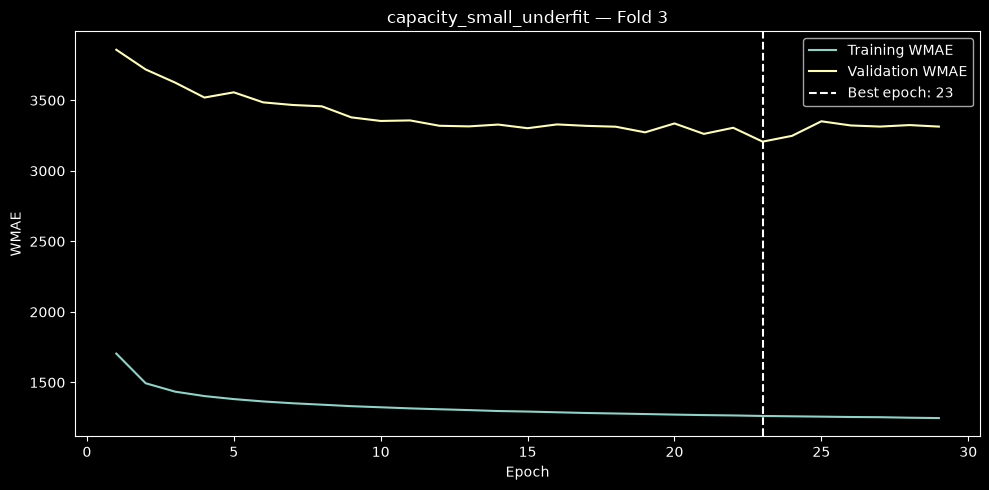

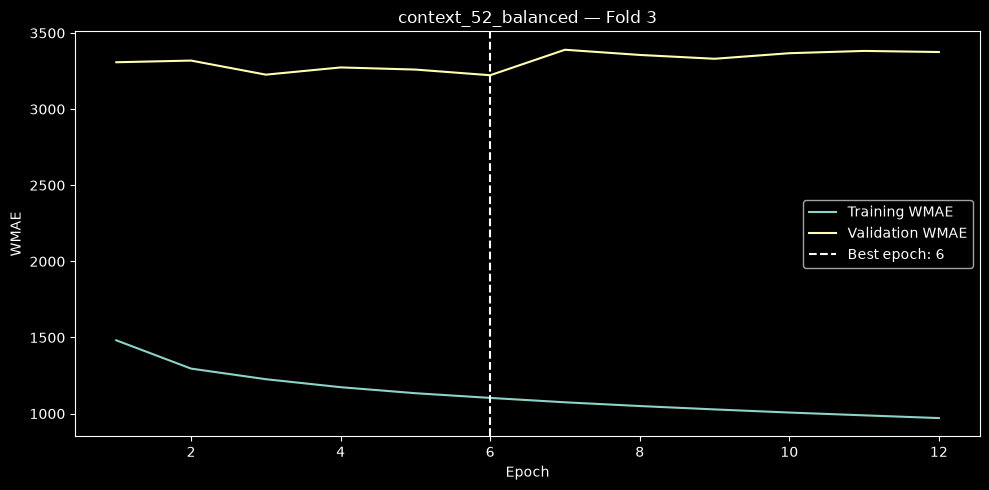

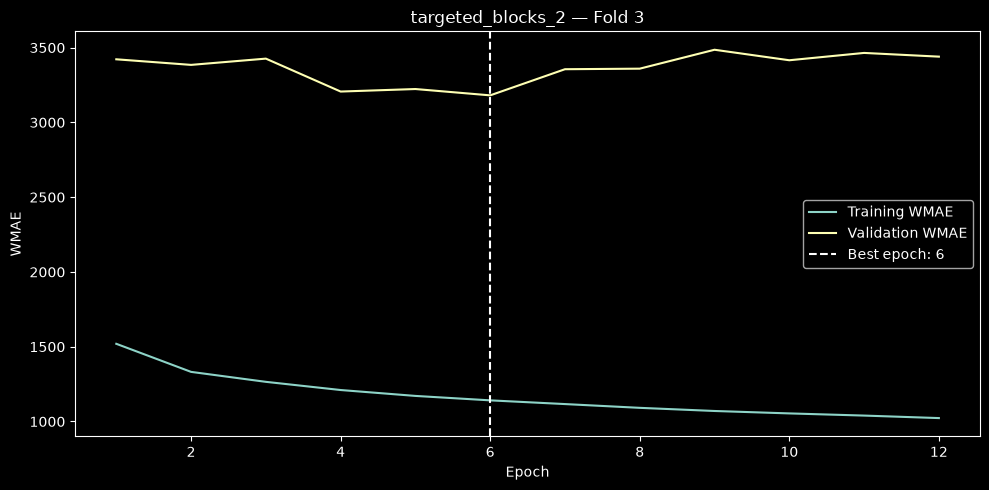

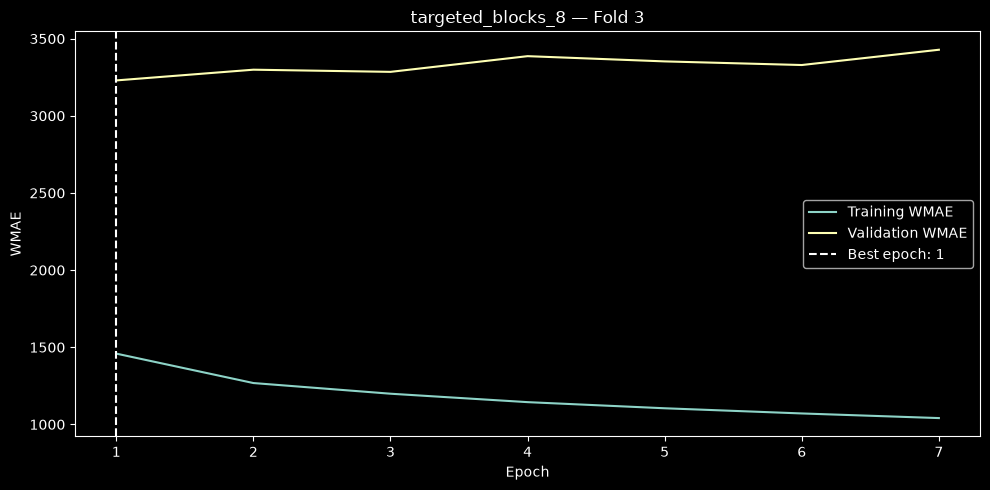

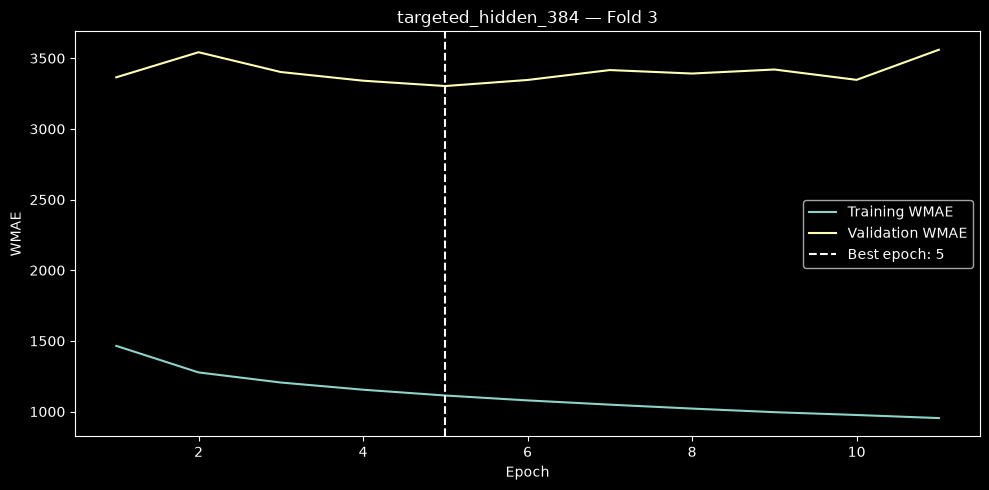

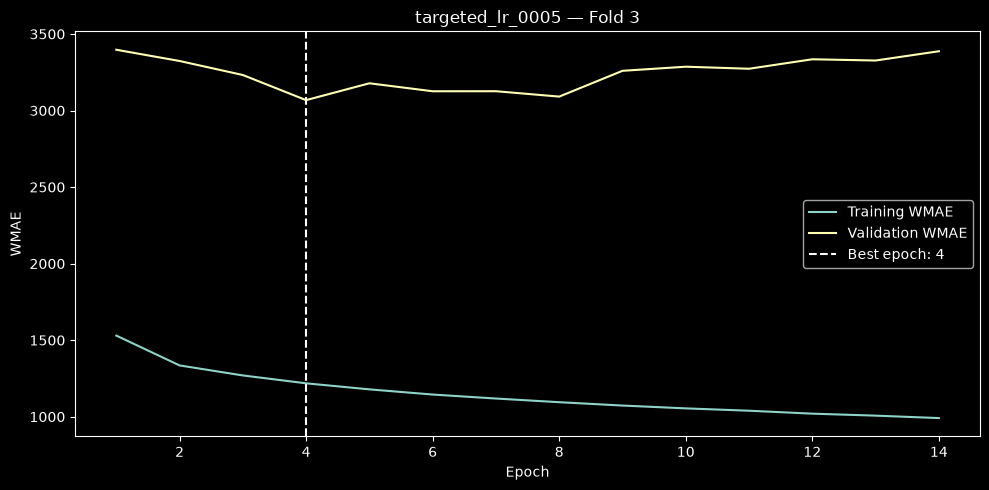

In [32]:
current_best_trial_id = (
    tuning_results.iloc[0][
        "trial_id"
    ]
)

diagnostic_trial_ids = [
    "capacity_small_underfit",
    "context_52_balanced",
    "targeted_blocks_2",
    "targeted_blocks_8",
    "targeted_hidden_384",
    "targeted_lr_0005",
]

if (
    current_best_trial_id
    not in diagnostic_trial_ids
):
    diagnostic_trial_ids.append(
        current_best_trial_id
    )

diagnostic_trial_ids = list(
    dict.fromkeys(
        diagnostic_trial_ids
    )
)

diagnostic_fold = 3

learning_curve_figures = {}

for trial_id in diagnostic_trial_ids:
    history = (
        trial_histories[
            trial_id
        ][diagnostic_fold]
    )

    best_epoch = int(
        trial_fold_results[
            trial_id
        ]
        .loc[
            lambda dataframe:
            dataframe["fold"]
            == diagnostic_fold,
            "best_epoch",
        ]
        .iloc[0]
    )

    figure, axis = plt.subplots(
        figsize=(10, 5)
    )

    axis.plot(
        history["epoch"],
        history[
            "train_wmae"
        ],
        label="Training WMAE",
    )

    axis.plot(
        history["epoch"],
        history[
            "validation_wmae"
        ],
        label="Validation WMAE",
    )

    axis.axvline(
        best_epoch,
        linestyle="--",
        label=(
            f"Best epoch: "
            f"{best_epoch}"
        ),
    )

    axis.set_title(
        f"{trial_id} — Fold "
        f"{diagnostic_fold}"
    )

    axis.set_xlabel(
        "Epoch"
    )

    axis.set_ylabel(
        "WMAE"
    )

    axis.legend()

    figure.tight_layout()
    plt.show()

    learning_curve_figures[
        trial_id
    ] = figure

# Best configuration selection

In [33]:
best_trial_id = (
    tuning_results.iloc[0][
        "trial_id"
    ]
)

best_trial = deepcopy(
    trial_registry[
        best_trial_id
    ]
)

best_trial_folds = (
    trial_fold_results[
        best_trial_id
    ]
)

final_epochs = max(
    1,
    int(
        np.median(
            best_trial_folds[
                "best_epoch"
            ]
        )
    ),
)

print(
    "Selected trial:",
    best_trial_id,
)

print(
    "Input length:",
    best_trial[
        "input_length"
    ],
)

print(
    "Capacity profile:",
    best_trial[
        "capacity_profile"
    ],
)

print(
    "Final epochs:",
    final_epochs,
)

tuning_results.head(10)

Selected trial: targeted_lr_0005
Input length: 52
Capacity profile: lower_learning_rate
Final epochs: 14


,trial_id,trial_name,capacity_profile,feature_set,preprocessing,input_length,parameter_count,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,cv_mae_mean,cv_rmse_mean,cv_generalization_gap_mean,best_epoch_median,neural_coverage_mean,training_windows_mean,fit_seconds
0,targeted_lr_0005,learning_rate_0005,lower_learning_rate,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,647428,"1,009.1737","2,387.9206",482.7459,"2,201.2761","5,226.5522","1,378.7470",14,0.9575,"39,829.6667",32.0762
1,context_52_balanced,context_52,balanced,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,647428,994.8112,"2,424.6526",564.4846,"2,226.8699","5,344.8909","1,429.8414",10,0.9575,"39,829.6667",24.0925
2,targeted_blocks_2,total_blocks_2,two_blocks,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,323714,"1,025.2502","2,427.4684",533.4378,"2,228.6931","5,316.2350","1,402.2182",6,0.9575,"39,829.6667",19.0371
3,targeted_blocks_8,total_blocks_8,eight_blocks,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,1294856,"1,107.5354","2,432.2840",563.8969,"2,252.3795","5,371.6747","1,324.7486",6,0.9575,"39,829.6667",21.4907
4,targeted_hidden_128,hidden_128,hidden_128,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,192772,"1,132.5284","2,433.7464",514.0632,"2,275.5933","5,351.4113","1,301.2180",8,0.9575,"39,829.6667",25.6526
5,capacity_large_unregularized,large_unregularized,large_unregularized,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,4400073,"1,042.7295","2,451.7147",619.5728,"2,234.0259","5,526.5071","1,408.9851",6,0.9575,"39,829.6667",51.0686
6,targeted_hidden_384,hidden_384,hidden_384,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,1364228,"1,023.1316","2,465.2180",592.7253,"2,251.2049","5,451.4996","1,442.0864",6,0.9575,"39,829.6667",23.9304
7,capacity_small_underfit,small_underfit,small_underfit,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,11777,"1,259.8622","2,470.8706",520.5942,"2,274.4930","5,478.2783","1,211.0084",17,0.9575,"39,829.6667",33.8876
8,capacity_large_regularized,large_regularized,large_regularized,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,52,4400073,"1,060.2151","2,483.6584",641.0027,"2,236.2979","5,582.4341","1,423.4434",6,0.9575,"39,829.6667",57.7104
9,targeted_context_39,context_39,context_diagnostic,target_only_input39_v1,neural_per_series_median_mad_scaling_v1,39,620752,"1,805.5735","2,883.5023",834.8360,"2,722.5231","6,669.6779","1,077.9288",6,0.9588,"76,673.0000",38.9006


## Fixed-epoch final training

In [34]:
def train_final_model(
    configuration: dict,
    training_rows: pd.DataFrame,
    all_series: pd.DataFrame,
    number_of_epochs: int,
    run,
) -> tuple[
    nn.Module,
    dict,
    float,
    pd.DataFrame,
]:
    set_seed(
        DEFAULT_RANDOM_SEED
    )

    panel_state = build_panel_state(
        training_rows=training_rows,
        all_series=all_series,
    )

    dataset = PanelWindowDataset(
        panel_state=panel_state,
        input_length=configuration[
            "input_length"
        ],
        horizon=FORECAST_HORIZON,
        min_input_coverage=(
            MIN_INPUT_COVERAGE
        ),
    )

    generator = torch.Generator()

    generator.manual_seed(
        DEFAULT_RANDOM_SEED
    )

    loader = DataLoader(
        dataset,
        batch_size=configuration[
            "batch_size"
        ],
        shuffle=True,
        num_workers=0,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        generator=generator,
    )

    model = build_model(
        configuration
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=configuration[
            "learning_rate"
        ],
        weight_decay=configuration[
            "weight_decay"
        ],
    )

    history = []

    fit_start = time.perf_counter()

    for epoch in range(
        1,
        number_of_epochs + 1,
    ):
        model.train()

        weighted_error_sum = 0.0
        weight_sum = 0.0

        for (
            inputs,
            targets,
            target_mask,
            horizon_weights,
            scales,
        ) in loader:
            inputs = inputs.to(
                DEVICE,
                non_blocking=True,
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True,
            )

            target_mask = (
                target_mask.to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            horizon_weights = (
                horizon_weights.to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            scales = scales.to(
                DEVICE,
                non_blocking=True,
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            predictions = model(inputs)

            loss = weighted_mae_loss(
                predictions=predictions,
                targets=targets,
                target_mask=target_mask,
                horizon_weights=(
                    horizon_weights
                ),
                scales=scales,
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=(
                    GRADIENT_CLIP_NORM
                ),
            )

            optimizer.step()

            with torch.no_grad():
                combined_weights = (
                    target_mask
                    * horizon_weights
                )

                raw_absolute_error = (
                    predictions - targets
                ).abs() * scales.unsqueeze(
                    1
                )

                weighted_error_sum += (
                    raw_absolute_error
                    .mul(
                        combined_weights
                    )
                    .sum()
                    .item()
                )

                weight_sum += (
                    combined_weights
                    .sum()
                    .item()
                )

        train_wmae = (
            weighted_error_sum
            / max(weight_sum, 1.0)
        )

        history.append(
            {
                "epoch": epoch,
                "train_wmae": (
                    train_wmae
                ),
            }
        )

        run.log(
            {
                "epoch": epoch,
                "train_wmae": (
                    train_wmae
                ),
            },
            step=epoch,
        )

    fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    return (
        model,
        panel_state,
        fit_seconds,
        pd.DataFrame(history),
    )

## Recursive 39-week forecasting

In [35]:
@torch.no_grad()
def recursive_forecast(
    model: nn.Module,
    panel_state: dict,
    holdout_rows: pd.DataFrame,
    input_length: int,
) -> tuple[
    dict[str, float],
    pd.DataFrame,
]:
    model.eval()

    holdout_rows = (
        holdout_rows
        .sort_values(
            ["Date", "Store", "Dept"]
        )
        .reset_index(drop=True)
        .copy()
    )

    forecast_dates = (
        pd.DatetimeIndex(
            holdout_rows[
                "Date"
            ]
            .drop_duplicates()
            .sort_values()
        )
    )

    if (
        len(forecast_dates)
        % FORECAST_HORIZON
        != 0
    ):
        raise ValueError(
            "Holdout horizon must be "
            "divisible by forecast horizon."
        )

    history_scaled = (
        panel_state[
            "filled_scaled"
        ].copy()
    )

    initial_coverage = (
        panel_state[
            "observed"
        ][
            :,
            -input_length:
        ]
        .mean(axis=1)
    )

    eligible = (
        initial_coverage
        >= MIN_INPUT_COVERAGE
    )

    eligible_indices = np.flatnonzero(
        eligible
    )

    prediction_frames = []

    for block_start in range(
        0,
        len(forecast_dates),
        FORECAST_HORIZON,
    ):
        block_dates = (
            forecast_dates[
                block_start:
                block_start
                + FORECAST_HORIZON
            ]
        )

        block_scaled = np.zeros(
            (
                len(
                    panel_state[
                        "series_frame"
                    ]
                ),
                FORECAST_HORIZON,
            ),
            dtype=np.float32,
        )

        for batch_start in range(
            0,
            len(eligible_indices),
            BATCH_SIZE,
        ):
            batch_indices = (
                eligible_indices[
                    batch_start:
                    batch_start
                    + BATCH_SIZE
                ]
            )

            batch_inputs = (
                torch.from_numpy(
                    history_scaled[
                        batch_indices,
                        -input_length:,
                    ]
                )
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            batch_predictions = (
                model(batch_inputs)
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            block_scaled[
                batch_indices
            ] = batch_predictions

        block_raw = (
            block_scaled
            * panel_state[
                "scales"
            ][:, None]
            + panel_state[
                "locations"
            ][:, None]
        )

        eligible_series = (
            panel_state[
                "series_frame"
            ]
            .iloc[eligible_indices]
            .reset_index(drop=True)
        )

        block_frame = (
            eligible_series
            .loc[
                eligible_series
                .index
                .repeat(
                    FORECAST_HORIZON
                )
            ]
            .reset_index(drop=True)
        )

        block_frame["Date"] = np.tile(
            block_dates.to_numpy(),
            len(eligible_series),
        )

        block_frame[
            "ModelPrediction"
        ] = (
            block_raw[
                eligible_indices
            ]
            .reshape(-1)
        )

        prediction_frames.append(
            block_frame
        )

        history_scaled = (
            np.concatenate(
                [
                    history_scaled,
                    block_scaled,
                ],
                axis=1,
            )
        )

    model_predictions = pd.concat(
        prediction_frames,
        ignore_index=True,
    )

    result = holdout_rows.merge(
        model_predictions,
        on=[
            "Store",
            "Dept",
            "Date",
        ],
        how="left",
        validate="many_to_one",
    )

    fallback_predictions = (
        make_fallback_predictions(
            rows=result,
            panel_state=panel_state,
        )
    )

    model_mask = (
        result[
            "ModelPrediction"
        ].notna()
    )

    result["Prediction"] = np.where(
        model_mask,
        result[
            "ModelPrediction"
        ],
        fallback_predictions,
    )

    result["AbsoluteError"] = (
        result["Weekly_Sales"]
        - result["Prediction"]
    ).abs()

    metrics = {
        "wmae": weighted_mae(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result[
                "Prediction"
            ],
            is_holiday=result[
                "IsHoliday"
            ],
        ),
        "mae": mean_absolute_error(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result[
                "Prediction"
            ],
        ),
        "rmse": root_mean_squared_error(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result[
                "Prediction"
            ],
        ),
        "neural_coverage": float(
            model_mask.mean()
        ),
    }

    return metrics, result

# Final W&B training and evaluation

In [36]:
best_cv_result = (
    tuning_results.iloc[0]
)

final_run_name = make_run_name(
    architecture=ARCHITECTURE,
    stage="final",
    feature_set=best_trial[
        "feature_set"
    ],
    trial_name="best",
)

final_parameters = (
    build_common_parameters(
        architecture=ARCHITECTURE,
        stage="final",
        feature_set=best_trial[
            "feature_set"
        ],
        preprocessing=best_trial[
            "preprocessing"
        ],
        evaluation_scope=(
            "full_dataset"
        ),
        forecast_strategy=(
            "recursive_13x3"
        ),
        series_count=series_count,
        extra_parameters={
            **{
                key: value
                for key, value
                in best_trial.items()
                if key not in {
                    "trial_id",
                    "trial_name",
                    "feature_set",
                    "preprocessing",
                }
            },
            "final_epochs": (
                final_epochs
            ),
            "selected_trial_id": (
                best_trial_id
            ),
        },
    )
)

all_final_series = pd.concat(
    [
        final_split.train[
            ["Store", "Dept"]
        ],
        final_split.validation[
            ["Store", "Dept"]
        ],
    ],
    ignore_index=True,
)

with wandb_run(
    run_name=final_run_name,
    group=WANDB_GROUP,
    job_type="final_training",
    config=final_parameters,
    tags=[
        "nbeats",
        "final",
        "full_dataset",
    ],
) as final_run:
    (
        final_model,
        final_panel_state,
        final_fit_seconds,
        final_training_history,
    ) = train_final_model(
        configuration=best_trial,
        training_rows=(
            final_split.train
        ),
        all_series=(
            all_final_series
        ),
        number_of_epochs=(
            final_epochs
        ),
        run=final_run,
    )

    predict_start = (
        time.perf_counter()
    )

    (
        holdout_metrics,
        holdout_prediction_frame,
    ) = recursive_forecast(
        model=final_model,
        panel_state=(
            final_panel_state
        ),
        holdout_rows=(
            final_split.validation
        ),
        input_length=(
            best_trial[
                "input_length"
            ]
        ),
    )

    final_predict_seconds = (
        time.perf_counter()
        - predict_start
    )

    final_metrics = {
        "cv_wmae_mean": float(
            best_cv_result[
                "cv_wmae_mean"
            ]
        ),
        "cv_wmae_std": float(
            best_cv_result[
                "cv_wmae_std"
            ]
        ),
        "holdout_wmae": float(
            holdout_metrics[
                "wmae"
            ]
        ),
        "holdout_mae": float(
            holdout_metrics[
                "mae"
            ]
        ),
        "holdout_rmse": float(
            holdout_metrics[
                "rmse"
            ]
        ),
    }

    final_run.summary.update(
        {
            **final_metrics,
            "neural_coverage": (
                holdout_metrics[
                    "neural_coverage"
                ]
            ),
            "fit_seconds": (
                final_fit_seconds
            ),
            "predict_seconds": (
                final_predict_seconds
            ),
            "final_epochs": (
                final_epochs
            ),
            "parameter_count": (
                count_parameters(
                    final_model
                )
            ),
        }
    )

    final_run.log(
        {
            "holdout_predictions": (
                wandb.Table(
                    dataframe=(
                        holdout_prediction_frame[
                            [
                                "Store",
                                "Dept",
                                "Date",
                                "Weekly_Sales",
                                "Prediction",
                                "IsHoliday",
                                "AbsoluteError",
                            ]
                        ]
                    )
                )
            ),
            "tuning_results": (
                wandb.Table(
                    dataframe=(
                        tuning_results
                    )
                )
            ),
        }
    )

    with TemporaryDirectory() as (
        temporary_directory
    ):
        temporary_path = Path(
            temporary_directory
        )

        checkpoint_path = (
            temporary_path
            / "nbeats_final.pt"
        )

        tuning_path = (
            temporary_path
            / "tuning_results.csv"
        )

        predictions_path = (
            temporary_path
            / "holdout_predictions.csv"
        )

        history_path = (
            temporary_path
            / "training_history.csv"
        )

        configuration_path = (
            temporary_path
            / "configuration.json"
        )

        checkpoint = {
            "model_state_dict": (
                {
                    key: value
                    .detach()
                    .cpu()
                    for key, value
                    in final_model
                    .state_dict()
                    .items()
                }
            ),
            "model_configuration": (
                best_trial
            ),
            "forecast_horizon": (
                FORECAST_HORIZON
            ),
            "final_epochs": (
                final_epochs
            ),
            "series_frame": (
                final_panel_state[
                    "series_frame"
                ]
            ),
            "locations": (
                final_panel_state[
                    "locations"
                ]
            ),
            "scales": (
                final_panel_state[
                    "scales"
                ]
            ),
            "training_end_date": str(
                final_split.train[
                    "Date"
                ].max()
            ),
        }

        torch.save(
            checkpoint,
            checkpoint_path,
        )

        tuning_results.to_csv(
            tuning_path,
            index=False,
        )

        holdout_prediction_frame.to_csv(
            predictions_path,
            index=False,
        )

        final_training_history.to_csv(
            history_path,
            index=False,
        )

        configuration_path.write_text(
            json.dumps(
                final_parameters,
                indent=2,
                default=str,
            ),
            encoding="utf-8",
        )

        reloaded_checkpoint = (
            torch.load(
                checkpoint_path,
                map_location=DEVICE,
                weights_only=False,
            )
        )

        reloaded_model = build_model(
            reloaded_checkpoint[
                "model_configuration"
            ]
        ).to(DEVICE)

        reloaded_model.load_state_dict(
            reloaded_checkpoint[
                "model_state_dict"
            ]
        )

        reloaded_model.eval()

        sample_inputs = (
            torch.from_numpy(
                final_panel_state[
                    "filled_scaled"
                ][
                    :32,
                    -best_trial[
                        "input_length"
                    ]:,
                ]
            )
            .to(DEVICE)
        )

        final_model.eval()

        with torch.no_grad():
            original_sample = (
                final_model(
                    sample_inputs
                )
            )

            reloaded_sample = (
                reloaded_model(
                    sample_inputs
                )
            )

        reload_max_abs_diff = float(
            (
                original_sample
                - reloaded_sample
            )
            .abs()
            .max()
            .item()
        )

        np.testing.assert_allclose(
            original_sample
            .detach()
            .cpu()
            .numpy(),
            reloaded_sample
            .detach()
            .cpu()
            .numpy(),
            rtol=1e-6,
            atol=1e-6,
        )

        final_run.summary[
            "checkpoint_reload_"
            "max_abs_diff"
        ] = reload_max_abs_diff

        artifact = wandb.Artifact(
            name=(
                "nbeats-final-model"
            ),
            type="model",
            metadata={
                **final_metrics,
                "selected_trial_id": (
                    best_trial_id
                ),
                "final_epochs": (
                    final_epochs
                ),
                "neural_coverage": (
                    holdout_metrics[
                        "neural_coverage"
                    ]
                ),
            },
        )

        artifact.add_file(
            str(checkpoint_path)
        )

        artifact.add_file(
            str(configuration_path)
        )

        artifact.add_file(
            str(tuning_path)
        )

        artifact.add_file(
            str(predictions_path)
        )

        artifact.add_file(
            str(history_path)
        )

        final_run.log_artifact(
            artifact
        )

print(
    "Final run:",
    final_run_name,
)

print(final_metrics)

print(
    "Neural coverage:",
    f"{holdout_metrics['neural_coverage']:.2%}",
)

wandb: setting up run b3sur8bs
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /home/xizusha/Documents/ML/walmart-store-sales-forecasting/notebooks/wandb/run-20260710_175310-b3sur8bs
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run nbeats__final__target_only_input52_v1__best__s42
wandb: ⭐️ View project at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting
wandb: 🚀 View run at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting/runs/b3sur8bs
wandb: uploading artifact run-b3sur8bs-holdout_predictions; uploading artifact run-b3sur8bs-tuning_results; uploading artifact nbeats-final-model; updating run metadata
wandb: uploading artifact run-b3sur8bs-holdout_predictions; uploading artifact run-b3sur8bs-tuning_results; uploading artifact nbeats-final-model
wandb: uploading artifact run-b3sur8bs-holdout_predictions; uploading artifact run-b3sur8bs-tuning_results; uploading art

Final run: nbeats__final__target_only_input52_v1__best__s42
{'cv_wmae_mean': 2387.9206292576805, 'cv_wmae_std': 482.74588039976004, 'holdout_wmae': 2019.1841677567413, 'holdout_mae': 2014.087143841023, 'holdout_rmse': 4217.007356021682}
Neural coverage: 95.75%


## Holdout prediction diagnostics

In [37]:
holiday_diagnostics = (
    holdout_prediction_frame
    .groupby("IsHoliday")
    .agg(
        rows=(
            "Prediction",
            "size",
        ),
        mean_actual=(
            "Weekly_Sales",
            "mean",
        ),
        mean_prediction=(
            "Prediction",
            "mean",
        ),
        mean_absolute_error=(
            "AbsoluteError",
            "mean",
        ),
    )
)

holiday_diagnostics

,rows,mean_actual,mean_prediction,mean_absolute_error
IsHoliday,,,,
False,109621,"15,808.0926","15,366.8389","2,012.4661"
True,5967,"16,480.5543","15,569.4980","2,043.8680"


In [38]:
holdout_dates = (
    holdout_prediction_frame[
        "Date"
    ]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

date_to_block = {
    date: (
        index
        // FORECAST_HORIZON
        + 1
    )
    for index, date in enumerate(
        holdout_dates
    )
}

holdout_prediction_frame[
    "forecast_block"
] = (
    holdout_prediction_frame[
        "Date"
    ].map(date_to_block)
)

recursive_block_diagnostics = (
    holdout_prediction_frame
    .groupby("forecast_block")
    .apply(
        lambda group: pd.Series(
            {
                "rows": len(group),
                "wmae": weighted_mae(
                    y_true=group[
                        "Weekly_Sales"
                    ],
                    y_pred=group[
                        "Prediction"
                    ],
                    is_holiday=group[
                        "IsHoliday"
                    ],
                ),
                "mae": (
                    group[
                        "AbsoluteError"
                    ].mean()
                ),
            }
        ),
        include_groups=False,
    )
)

recursive_block_diagnostics

,rows,wmae,mae
forecast_block,,,
1,"38,685.0000","1,949.8735","1,950.1483"
2,"38,373.0000","2,049.6993","2,049.6993"
3,"38,530.0000","2,065.6646","2,042.8161"


## Save result

In [39]:
result_row = build_result_row(
    architecture=ARCHITECTURE,
    run_name=final_run_name,
    stage="final",
    tracker="wandb",
    feature_set=best_trial[
        "feature_set"
    ],
    preprocessing=best_trial[
        "preprocessing"
    ],
    evaluation_scope=(
        "full_dataset"
    ),
    forecast_strategy=(
        "recursive_13x3"
    ),
    series_count=series_count,
    metrics=final_metrics,
    fit_seconds=(
        final_fit_seconds
    ),
    predict_seconds=(
        final_predict_seconds
    ),
    notes=(
        "Global generic N-BEATS. "
        "Configuration selected by "
        "mean CV WMAE. Final 39-week "
        "holdout forecast recursively "
        "in three 13-week blocks."
    ),
)

save_architecture_result(
    result_row
)

pd.DataFrame(
    [result_row]
)

,architecture,run_name,stage,tracker,feature_set,preprocessing,validation_id,data_version,evaluation_scope,forecast_strategy,series_count,random_seed,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,fit_seconds,predict_seconds,notes
0,nbeats,nbeats__final__target_only_input52_v1__best__s42,final,wandb,target_only_input52_v1,neural_per_series_median_mad_scaling_v1,expanding_3x13_holdout_39_v1,processed_v1,full_dataset,recursive_13x3,3306,42,"2,387.9206",482.7459,"2,019.1842","2,014.0871","4,217.0074",23.3113,0.1563,Global generic N-BEATS. Configuration selected...


## Model comparison

In [40]:
from walmart_forecasting.paths import (
    TABLES_DIR,
)


result_paths = [
    TABLES_DIR
    / "lightgbm_final.csv",
    TABLES_DIR
    / "xgboost_final.csv",
    TABLES_DIR
    / "nbeats_final.csv",
]

comparison_frames = []

for result_path in result_paths:
    if result_path.exists():
        comparison_frames.append(
            pd.read_csv(
                result_path
            )
        )

if comparison_frames:
    model_comparison = (
        pd.concat(
            comparison_frames,
            ignore_index=True,
        )
        .sort_values(
            "holdout_wmae"
        )
        .reset_index(drop=True)
    )

    model_comparison = (
        model_comparison[
            [
                "architecture",
                "feature_set",
                "forecast_strategy",
                "cv_wmae_mean",
                "cv_wmae_std",
                "holdout_wmae",
                "holdout_mae",
                "holdout_rmse",
                "fit_seconds",
                "predict_seconds",
            ]
        ]
    )
else:
    model_comparison = pd.DataFrame()

model_comparison

,architecture,feature_set,forecast_strategy,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,fit_seconds,predict_seconds
0,lightgbm,core_calendar_lag52_v1,global_tabular,"1,949.1676",497.7775,"1,707.1122","1,713.6278","3,646.4237",29.4280,0.6944
1,xgboost,core_calendar_lag52_v1,global_tabular,"2,073.0701",600.1492,"1,745.8123","1,740.7133","3,720.5687",105.1422,1.2715
2,nbeats,target_only_input52_v1,recursive_13x3,"2,387.9206",482.7459,"2,019.1842","2,014.0871","4,217.0074",23.3113,0.1563
